In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
import joblib
import numpy as np
import seaborn as sns


In [2]:
df = pd.read_csv("../data/gold/base_gold_analitica.csv")

df = df.sort_values(["id_aluno", "ano_ref"])

In [3]:
# Próximo ano observado do aluno
df["ano_ref_futuro"] = df.groupby("id_aluno")["ano_ref"].shift(-1)

# Último ano disponível na base
ano_max = df["ano_ref"].max()

# Verifica se o próximo registro é exatamente o ano seguinte
df["tem_ano_seguinte"] = df["ano_ref_futuro"] == df["ano_ref"] + 1

# Variações futuras
df["delta_ida_futuro"] = df.groupby("id_aluno")["ida"].shift(-1) - df["ida"]
df["delta_ieg_futuro"] = df.groupby("id_aluno")["ieg"].shift(-1) - df["ieg"]
df["delta_defasagem_futuro"] = df.groupby("id_aluno")["defasagem"].shift(-1) - df["defasagem"]

df.loc[~df["tem_ano_seguinte"], ["delta_ida_futuro", "delta_ieg_futuro", "delta_defasagem_futuro"]] = pd.NA

# Evasão / ausência no ano seguinte
df["evasao_futura"] = ~df["tem_ano_seguinte"]

# Último ano da base não pode ser classificado como evasão devido ausencia do ano 2025
df.loc[df["ano_ref"] == ano_max, "evasao_futura"] = pd.NA

C:\Users\andre\AppData\Local\Temp\ipykernel_4132\3909748931.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[df["ano_ref"] == ano_max, "evasao_futura"] = pd.NA


A ausência de registro do aluno no ano seguinte foi interpretada como evasão/saída da base, seguindo a lógica de movimentação utilizada no relatório PEDE. Dessa forma, o alvo de risco futuro considera queda no desempenho acadêmico, queda no engajamento, piora da defasagem ou ausência no período seguinte. O último ano da base foi excluído do treinamento, pois não há informação futura disponível para avaliar o desfecho.

In [4]:
df["risco_defasagem_futuro"] = (
    (df["delta_ida_futuro"] < 0) |
    (df["delta_ieg_futuro"] < 0) |
    (df["delta_defasagem_futuro"] < 0) |
    (df["evasao_futura"] == True)
)

# Último ano da base fica sem target
df.loc[df["ano_ref"] == ano_max, "risco_defasagem_futuro"] = pd.NA

df["risco_defasagem_futuro"] = df["risco_defasagem_futuro"].astype("Int64")

C:\Users\andre\AppData\Local\Temp\ipykernel_4132\2029546224.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[df["ano_ref"] == ano_max, "risco_defasagem_futuro"] = pd.NA


In [5]:
df[["ano_ref", "tem_ano_seguinte", "evasao_futura", "risco_defasagem_futuro"]].groupby(
    ["ano_ref", "tem_ano_seguinte", "evasao_futura", "risco_defasagem_futuro"],
    dropna=False
).size()

ano_ref  tem_ano_seguinte  evasao_futura  risco_defasagem_futuro
2022     False             True           1                          260
         True              False          0                          180
                                          1                          420
2023     False             True           1                          262
         True              False          0                          155
                                          1                          597
2024     False             NaN            <NA>                      1118
dtype: int64

In [6]:
features = [
    "fase",
    "idade",
    "defasagem",
    "ida",
    "ieg",
    "iaa",
    "ips",
    "ipp",
    "ipv",
    "ian",
    "matematica",
    "portugues",
    "ingles"
]

target = "risco_defasagem_futuro"

base_modelo = df[
    ["id_aluno", "ano_ref"] + features + [target]
].copy()

# Remove apenas linhas sem target
base_modelo = base_modelo.dropna(subset=[target])

# Converte target para inteiro
base_modelo[target] = base_modelo[target].astype(int)

print("Shape da base de modelo:", base_modelo.shape)

print("\nDistribuição absoluta do target:")
print(base_modelo[target].value_counts())

print("\nDistribuição percentual do target:")
print(base_modelo[target].value_counts(normalize=True))

Shape da base de modelo: (1874, 16)

Distribuição absoluta do target:
risco_defasagem_futuro
1    1539
0     335
Name: count, dtype: int64

Distribuição percentual do target:
risco_defasagem_futuro
1    0.821238
0    0.178762
Name: proportion, dtype: float64


In [7]:
nulos_features = (
    base_modelo[features]
    .isna()
    .mean()
    .sort_values(ascending=False)
)

nulos_features

ingles        0.670758
ipp           0.499466
matematica    0.042156
portugues     0.042156
ida           0.041089
ipv           0.040555
ieg           0.040555
ips           0.036820
iaa           0.033618
idade         0.000000
defasagem     0.000000
fase          0.000000
ian           0.000000
dtype: float64

In [10]:

X = base_modelo[features]
y = base_modelo[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

modelo = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)
y_proba = modelo.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("AUC:", roc_auc_score(y_test, y_proba))

print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.27      0.56      0.36        84
           1       0.87      0.67      0.76       385

    accuracy                           0.65       469
   macro avg       0.57      0.61      0.56       469
weighted avg       0.77      0.65      0.69       469

AUC: 0.6724335188620902
Matriz de Confusão:
[[ 47  37]
 [128 257]]


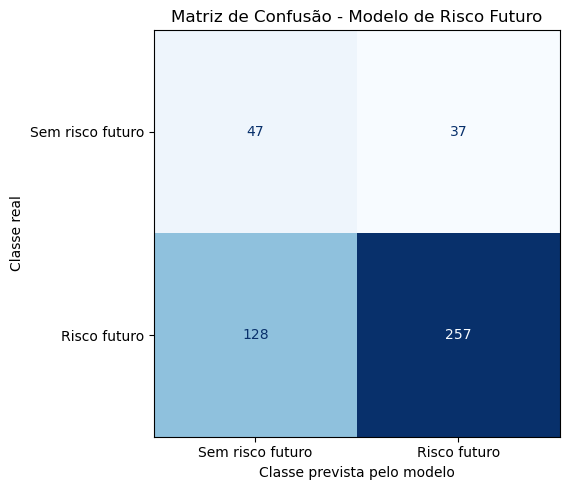

In [35]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Sem risco futuro", "Risco futuro"]
)

fig, ax = plt.subplots(figsize=(6,5))

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)

plt.title("Matriz de Confusão - Modelo de Risco Futuro")
plt.xlabel("Classe prevista pelo modelo")
plt.ylabel("Classe real")

plt.tight_layout()
plt.show()

In [36]:
modelo_sem_balanceamento = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

modelo_sem_balanceamento.fit(X_train, y_train)

y_pred_sem_bal = modelo_sem_balanceamento.predict(X_test)
y_proba_sem_bal = modelo_sem_balanceamento.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_sem_bal))
print("AUC:", roc_auc_score(y_test, y_proba_sem_bal))
print(confusion_matrix(y_test, y_pred_sem_bal))

              precision    recall  f1-score   support

           0       0.64      0.08      0.15        84
           1       0.83      0.99      0.90       385

    accuracy                           0.83       469
   macro avg       0.73      0.54      0.53       469
weighted avg       0.80      0.83      0.77       469

AUC: 0.6637445887445887
[[  7  77]
 [  4 381]]


In [11]:
modelo_rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        random_state=42,
        class_weight="balanced"
    ))
])

modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)
y_proba_rf = modelo_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, y_proba_rf))
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.34      0.50      0.41        84
           1       0.88      0.79      0.83       385

    accuracy                           0.74       469
   macro avg       0.61      0.65      0.62       469
weighted avg       0.78      0.74      0.76       469

AUC: 0.7248144712430425
[[ 42  42]
 [ 80 305]]


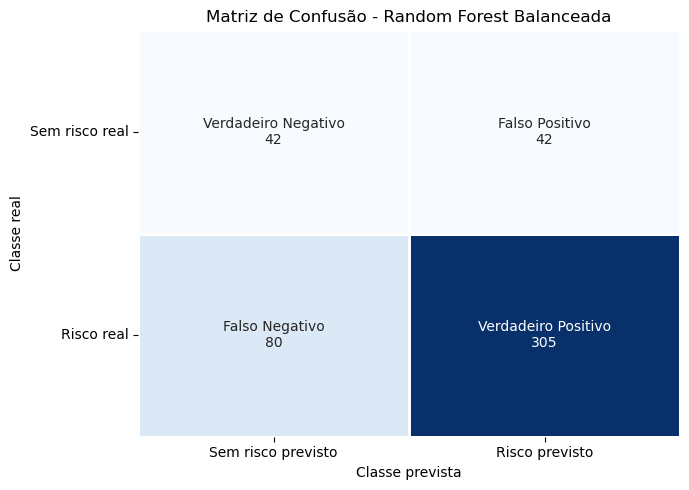

In [49]:
cm = confusion_matrix(y_test, y_pred_rf)

tn, fp, fn, tp = cm.ravel()

matriz_label = np.array([
    [f"Verdadeiro Negativo\n{tn}", f"Falso Positivo\n{fp}"],
    [f"Falso Negativo\n{fn}", f"Verdadeiro Positivo\n{tp}"]
])

matriz_valores = np.array([
    [tn, fp],
    [fn, tp]
])

plt.figure(figsize=(7,5))

sns.heatmap(
    matriz_valores,
    annot=matriz_label,
    fmt="",
    cmap="Blues",
    cbar=False,
    linewidths=1,
    linecolor="white"
)

plt.title("Matriz de Confusão - Random Forest Balanceada")
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")

plt.xticks(
    ticks=[0.5, 1.5],
    labels=["Sem risco previsto", "Risco previsto"]
)

plt.yticks(
    ticks=[0.5, 1.5],
    labels=["Sem risco real", "Risco real"],
    rotation=0
)

plt.tight_layout()
plt.show()

In [46]:
modelo_rf_sem_bal = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        random_state=42
    ))
])

modelo_rf_sem_bal.fit(X_train, y_train)

y_pred_rf_sem_bal = modelo_rf_sem_bal.predict(X_test)
y_proba_rf_sem_bal = modelo_rf_sem_bal.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf_sem_bal))
print("AUC:", roc_auc_score(y_test, y_proba_rf_sem_bal))
print(confusion_matrix(y_test, y_pred_rf_sem_bal))

              precision    recall  f1-score   support

           0       0.75      0.11      0.19        84
           1       0.84      0.99      0.91       385

    accuracy                           0.83       469
   macro avg       0.79      0.55      0.55       469
weighted avg       0.82      0.83      0.78       469

AUC: 0.7025819418676561
[[  9  75]
 [  3 382]]


In [12]:
modelo_rf_ajustado = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=500,
        max_depth=7,
        min_samples_leaf=5,
        random_state=42,
        class_weight="balanced"
    ))
])

modelo_rf_ajustado.fit(X_train, y_train)

y_pred_rf_ajustado = modelo_rf_ajustado.predict(X_test)
y_proba_rf_ajustado = modelo_rf_ajustado.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf_ajustado))
print("AUC:", roc_auc_score(y_test, y_proba_rf_ajustado))
print(confusion_matrix(y_test, y_pred_rf_ajustado))

              precision    recall  f1-score   support

           0       0.36      0.45      0.40        84
           1       0.87      0.83      0.85       385

    accuracy                           0.76       469
   macro avg       0.62      0.64      0.63       469
weighted avg       0.78      0.76      0.77       469

AUC: 0.7349876314162028
[[ 38  46]
 [ 67 318]]


Após os ajustes, o modelo Random Forest apresentou acurácia de 76% e AUC de 0,73, superando o desempenho da versão anterior. Embora tenha ocorrido leve redução na identificação da classe sem risco, o modelo reduziu falsos negativos e aumentou o número de alunos em risco corretamente identificados. Como o objetivo do projeto é apoiar ações preventivas, priorizou-se um modelo com melhor capacidade de detectar alunos em risco futuro.

In [14]:
Path("../data/gold").mkdir(parents=True, exist_ok=True)

base_modelo.to_csv("../data/gold/base_modelo_risco.csv", index=False)

# print(base_modelo.shape)

(1874, 16)


In [13]:
Path("../models").mkdir(parents=True, exist_ok=True)

joblib.dump(modelo_rf_ajustado, "../models/modelo_risco.pkl")

['../models/modelo_risco.pkl']